In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data= pd.read_csv("https://raw.githubusercontent.com/haram4th/ADsP/main/iris3.csv")
data.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [3]:
data['species'].unique()

array(['Iris-setosa', 'Iris-versicolor', 'Iris-virginica'], dtype=object)

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


<Axes: >

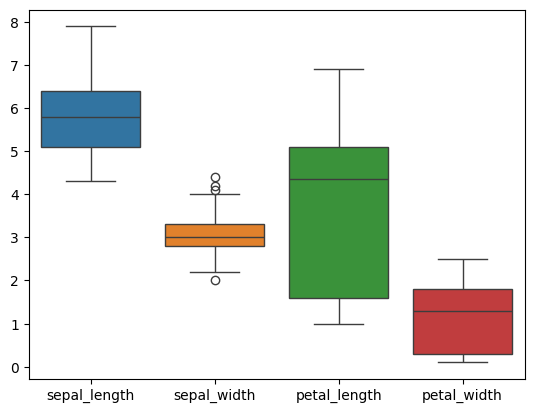

In [5]:
sns.boxplot(data)

In [6]:
data['species'].value_counts()

species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

In [7]:
X = data.drop("species", axis=1)
y = data["species"]

In [8]:
# from sklearn.preprocessing import LabelEncoder
# le = LabelEncoder()
# y = le.fit_transform(y)
# y

In [10]:
y = pd.get_dummies(y)
y

,Iris-setosa,Iris-versicolor,Iris-virginica
0,True,False,False
1,True,False,False
2,True,False,False
3,True,False,False
4,True,False,False
...,...,...,...
145,False,False,True
146,False,False,True
147,False,False,True
148,False,False,True


In [11]:
from sklearn.model_selection import train_test_split

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [13]:
X_train

,sepal_length,sepal_width,petal_length,petal_width
22,4.6,3.6,1.0,0.2
15,5.7,4.4,1.5,0.4
65,6.7,3.1,4.4,1.4
11,4.8,3.4,1.6,0.2
42,4.4,3.2,1.3,0.2
...,...,...,...,...
71,6.1,2.8,4.0,1.3
106,4.9,2.5,4.5,1.7
14,5.8,4.0,1.2,0.2
92,5.8,2.6,4.0,1.2


In [14]:
y_train

,Iris-setosa,Iris-versicolor,Iris-virginica
22,True,False,False
15,True,False,False
65,False,True,False
11,True,False,False
42,True,False,False
...,...,...,...
71,False,True,False
106,False,False,True
14,True,False,False
92,False,True,False


In [15]:
from sklearn.preprocessing import MinMaxScaler

In [16]:
mms = MinMaxScaler()
train_temp = mms.fit_transform(X_train)
test_temp = mms.transform(X_test)
mms_X_train = pd.DataFrame(train_temp, columns=X_train.columns, index=X_train.index)
mms_X_test = pd.DataFrame(test_temp, columns=X_test.columns, index=X_test.index)

In [17]:
mms_X_train

,sepal_length,sepal_width,petal_length,petal_width
22,0.088235,0.666667,0.000000,0.041667
15,0.411765,1.000000,0.087719,0.125000
65,0.705882,0.458333,0.596491,0.541667
11,0.147059,0.583333,0.105263,0.041667
42,0.029412,0.500000,0.052632,0.041667
...,...,...,...,...
71,0.529412,0.333333,0.526316,0.500000
106,0.176471,0.208333,0.614035,0.666667
14,0.441176,0.833333,0.035088,0.041667
92,0.441176,0.250000,0.526316,0.458333


In [18]:
mms_X_test

,sepal_length,sepal_width,petal_length,petal_width
73,0.529412,0.333333,0.649123,0.458333
18,0.411765,0.750000,0.122807,0.083333
118,1.000000,0.250000,1.035088,0.916667
78,0.500000,0.375000,0.614035,0.583333
76,0.735294,0.333333,0.666667,0.541667
31,0.323529,0.583333,0.087719,0.125000
64,0.382353,0.375000,0.456140,0.500000
141,0.764706,0.458333,0.719298,0.916667
68,0.558824,0.083333,0.614035,0.583333
82,0.441176,0.291667,0.508772,0.458333


In [19]:
y_test  # 다중분류

,Iris-setosa,Iris-versicolor,Iris-virginica
73,False,True,False
18,True,False,False
118,False,False,True
78,False,True,False
76,False,True,False
31,True,False,False
64,False,True,False
141,False,False,True
68,False,True,False
82,False,True,False


# 텐서플로로 다중분류 분석하기

Sequential API

In [22]:
from keras.models import Sequential
from keras.layers import Dense, Input

In [26]:
model = Sequential()
model.add(Input(shape=(mms_X_train.shape[1],))) # 입력층
model.add(Dense(16, activation='relu')) # 은닉층
model.add(Dense(8, activation='relu')) # 은닉층
model.add(Dense(4, activation='relu')) # 은닉층
model.add(Dense(3, activation='softmax')) # 출력층, 다중분류이므로 softmax
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 16)             │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 4)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 3)              │            15 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 267 (1.04 KB)

 Trainable params: 267 (1.04 KB)

 Non-trainable params: 0 (0.00 B)

* 다중분류의 경우 사용하는 loss
    * categorical_crossentropy: 종속변수 클래스가 3개 이상인 경우이고 one-hot encoding된 경우
    * sparse_categorical_crossentropy: 종속변수 클래스가 3개 이상인 경우이고 label encoding된 경우

Epoch 1/100


I0000 00:00:1747282213.214468    5037 service.cc:152] XLA service 0x7f004c009cf0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1747282213.214534    5037 service.cc:160]   StreamExecutor device (0): NVIDIA GeForce MX450, Compute Capability 7.5
2025-05-15 13:10:13.306162: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1747282213.786274    5037 cuda_dnn.cc:529] Loaded cuDNN version 90300


5/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.0652 - loss: 1.1051

I0000 00:00:1747282216.822242    5037 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


8/8 ━━━━━━━━━━━━━━━━━━━━ 9s 578ms/step - accuracy: 0.1005 - loss: 1.1028 - val_accuracy: 0.3000 - val_loss: 1.0934
Epoch 2/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.4668 - loss: 1.0889 - val_accuracy: 0.7000 - val_loss: 1.0805
Epoch 3/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.5900 - loss: 1.0775 - val_accuracy: 0.6667 - val_loss: 1.0708
Epoch 4/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.5332 - loss: 1.0669 - val_accuracy: 0.7000 - val_loss: 1.0629
Epoch 5/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.4578 - loss: 1.0608 - val_accuracy: 0.4000 - val_loss: 1.0557
Epoch 6/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.4223 - loss: 1.0521 - val_accuracy: 0.4000 - val_loss: 1.0464
Epoch 7/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.3814 - loss: 1.0449 - val_accuracy: 0.4000 - val_loss: 1.0376
Epoch 8/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.4087 - loss: 1.0294 - val_accuracy: 0.3667 - val_loss: 1.0284
Epo

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.6809 - loss: 0.6493 - val_accuracy: 0.6333 - val_loss: 0.6429
Epoch 53/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.6477 - loss: 0.6447 - val_accuracy: 0.6333 - val_loss: 0.6407
Epoch 54/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.7102 - loss: 0.6367 - val_accuracy: 0.6333 - val_loss: 0.6384
Epoch 55/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.6768 - loss: 0.6233 - val_accuracy: 0.6333 - val_loss: 0.6361
Epoch 56/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.6569 - loss: 0.6473 - val_accuracy: 0.6333 - val_loss: 0.6339
Epoch 57/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.6680 - loss: 0.6985 - val_accuracy: 0.6333 - val_loss: 0.6318
Epoch 58/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.6932 - loss: 0.6087 - val_accuracy: 0.6333 - val_loss: 0.6298
Epoch 59/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.6553 - loss: 0.6426 - val_accuracy: 0.6333 - val_loss: 0.62

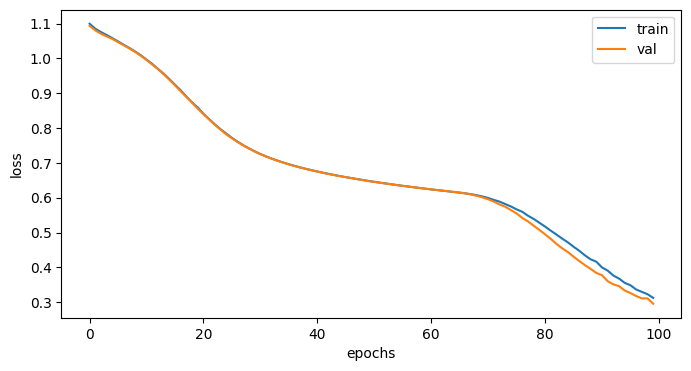

,Iris-setosa,Iris-versicolor,Iris-virginica,0,1,2
73,False,True,False,0.275691,0.562090,0.162220
18,True,False,False,0.995726,0.004147,0.000126
118,False,False,True,0.019924,0.026599,0.953477
78,False,True,False,0.220443,0.472477,0.307080
76,False,True,False,0.197199,0.447222,0.355579
31,True,False,False,0.989057,0.010486,0.000457
64,False,True,False,0.345154,0.558315,0.096530
141,False,False,True,0.038452,0.063873,0.897674
68,False,True,False,0.074752,0.159565,0.765682
82,False,True,False,0.302327,0.563978,0.133695


In [30]:
# 모델의 파라미터 세팅
model.compile(loss='categorical_crossentropy', 
              optimizer='adam', 
              metrics=['accuracy'])
history = model.fit(mms_X_train, y_train, epochs=100, batch_size=16, 
                    validation_data=(mms_X_test, y_test))
pred = model.predict(mms_X_test)
pred = pd.DataFrame(pred, index=y_test.index)
result = pd.concat([y_test, pred], axis=1)

plt.figure(figsize=(8,4))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel('epochs')
plt.ylabel('loss')
plt.legend(['train', 'val'])
plt.show()
result

Funtional API

In [28]:
from keras.models import Model

In [29]:
# 입력층
inputs = Input(shape=(mms_X_train.shape[1],))

# 은닉층
x = Dense(16, activation='relu')(inputs)
x = Dense(8, activation='relu')(x)
x = Dense(4, activation='relu')(x)

# 출력층
outputs = Dense(3, activation='softmax')(x)

# 모델 정의
model = Model(inputs=inputs, outputs=outputs)
model.summary()

Model: "functional_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 4)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 16)             │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 4)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 3)              │            15 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 267 (1.04 KB)

 Trainable params: 267 (1.04 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 6s 390ms/step - accuracy: 0.9152 - loss: 0.3520 - val_accuracy: 0.9667 - val_loss: 0.2919
Epoch 2/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.9300 - loss: 0.3325 - val_accuracy: 0.9667 - val_loss: 0.2878
Epoch 3/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.9531 - loss: 0.2914 - val_accuracy: 0.9667 - val_loss: 0.2833
Epoch 4/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.9672 - loss: 0.2707 - val_accuracy: 0.9667 - val_loss: 0.2797
Epoch 5/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.9435 - loss: 0.2873 - val_accuracy: 0.9667 - val_loss: 0.2815
Epoch 6/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.9614 - loss: 0.3005 - val_accuracy: 0.9667 - val_loss: 0.2746
Epoch 7/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.9582 - loss: 0.2916 - val_accuracy: 0.9667 - val_loss: 0.2703
Epoch 8/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.9658 - loss: 0.2555 - val_accuracy: 0.9667 - val_loss

Epoch 52/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.9721 - loss: 0.1215 - val_accuracy: 0.9667 - val_loss: 0.1494
Epoch 53/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.9766 - loss: 0.0987 - val_accuracy: 0.9667 - val_loss: 0.1482
Epoch 54/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.9689 - loss: 0.1246 - val_accuracy: 0.9667 - val_loss: 0.1460
Epoch 55/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.9835 - loss: 0.0969 - val_accuracy: 0.9667 - val_loss: 0.1450
Epoch 56/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.9445 - loss: 0.1316 - val_accuracy: 0.9667 - val_loss: 0.1423
Epoch 57/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.9758 - loss: 0.1166 - val_accuracy: 0.9667 - val_loss: 0.1410
Epoch 58/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.9700 - loss: 0.1291 - val_accuracy: 0.9667 - val_loss: 0.1392
Epoch 59/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.9748 - loss: 0.1104 - val_accuracy: 0.9667 - v

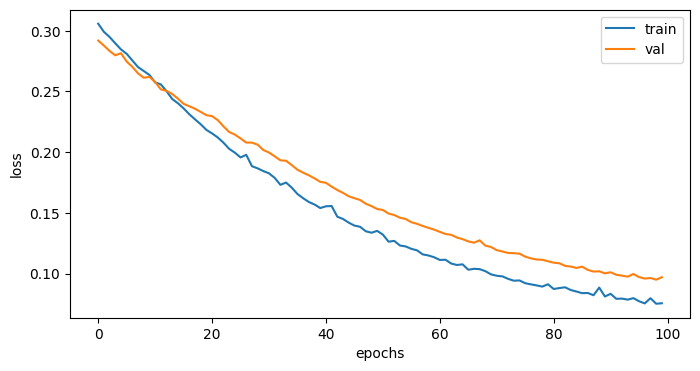

,Iris-setosa,Iris-versicolor,Iris-virginica,0,1,2
73,False,True,False,0.029485,0.962177,8.338422e-03
18,True,False,False,0.999097,0.000903,3.931926e-09
118,False,False,True,0.000002,0.000071,9.999273e-01
78,False,True,False,0.027329,0.900623,7.204791e-02
76,False,True,False,0.027088,0.880493,9.241860e-02
31,True,False,False,0.996907,0.003093,4.144283e-08
64,False,True,False,0.025823,0.973479,6.981998e-04
141,False,False,True,0.000041,0.001259,9.987006e-01
68,False,True,False,0.006406,0.144544,8.490502e-01
82,False,True,False,0.029285,0.968563,2.151966e-03


In [31]:
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
history = model.fit(mms_X_train, y_train, epochs=100, batch_size=16, 
                    validation_data=(mms_X_test, y_test))
pred = model.predict(mms_X_test)
pred = pd.DataFrame(pred, index=y_test.index)
result = pd.concat([y_test, pred], axis=1)

plt.figure(figsize=(8,4))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel('epochs')
plt.ylabel('loss')
plt.legend(['train', 'val'])
plt.show()
result

Subclass API

In [32]:
class Iris(Model):
    def __init__(self):
        super(Iris, self).__init__()
        self.dense1 = Dense(16, activation='relu')
        self.dense2 = Dense(8, activation='relu')        
        self.dense3 = Dense(4, activation='relu')
        self.classifier = Dense(3, activation='softmax')
        
    def call(self, inputs):
        x = self.dense1(inputs)
        x = self.dense2(x)
        x = self.dense3(x)        
        return self.classifier(x)

Epoch 1/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - accuracy: 0.3479 - loss: 1.0954 - val_accuracy: 0.3333 - val_loss: 1.0919
Epoch 2/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.3354 - loss: 1.0910 - val_accuracy: 0.3333 - val_loss: 1.0854
Epoch 3/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.3615 - loss: 1.0827 - val_accuracy: 0.3333 - val_loss: 1.0786
Epoch 4/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.3823 - loss: 1.0738 - val_accuracy: 0.3333 - val_loss: 1.0723
Epoch 5/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.3179 - loss: 1.0732 - val_accuracy: 0.3333 - val_loss: 1.0669
Epoch 6/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - accuracy: 0.3785 - loss: 1.0669 - val_accuracy: 0.3333 - val_loss: 1.0622
Epoch 7/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.3779 - loss: 1.0575 - val_accuracy: 0.3333 - val_loss: 1.0573
Epoch 8/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.3760 - loss: 1.0562 - val_accuracy: 0.3667 - val_loss: 1

Epoch 52/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.7044 - loss: 0.6919 - val_accuracy: 0.6333 - val_loss: 0.7122
Epoch 53/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.6762 - loss: 0.7187 - val_accuracy: 0.6333 - val_loss: 0.7082
Epoch 54/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.6731 - loss: 0.7332 - val_accuracy: 0.6333 - val_loss: 0.7047
Epoch 55/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.6762 - loss: 0.6893 - val_accuracy: 0.6333 - val_loss: 0.7014
Epoch 56/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.6679 - loss: 0.7039 - val_accuracy: 0.6333 - val_loss: 0.6981
Epoch 57/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.6731 - loss: 0.7017 - val_accuracy: 0.6333 - val_loss: 0.6950
Epoch 58/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.6377 - loss: 0.7098 - val_accuracy: 0.6333 - val_loss: 0.6921
Epoch 59/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.6762 - loss: 0.7044 - val_accuracy: 0.6333 - v

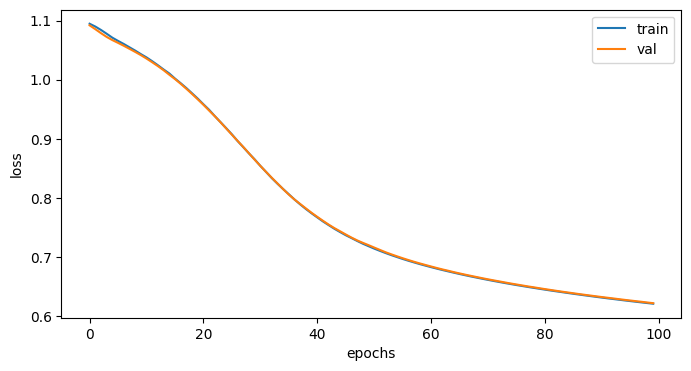

,Iris-setosa,Iris-versicolor,Iris-virginica,0,1,2
73,False,True,False,0.206106,0.405060,0.388834
18,True,False,False,0.993678,0.003071,0.003251
118,False,False,True,0.206106,0.405060,0.388834
78,False,True,False,0.206106,0.405060,0.388834
76,False,True,False,0.206106,0.405060,0.388834
31,True,False,False,0.981400,0.009116,0.009485
64,False,True,False,0.206106,0.405060,0.388834
141,False,False,True,0.206106,0.405060,0.388834
68,False,True,False,0.206106,0.405060,0.388834
82,False,True,False,0.206106,0.405060,0.388834


In [33]:
model2 = Iris()
model2.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
history = model2.fit(mms_X_train, y_train, epochs=100, batch_size=32, 
                    validation_data=(mms_X_test, y_test))
pred = model2.predict(mms_X_test)
pred = pd.DataFrame(pred, index=y_test.index)
result = pd.concat([y_test, pred], axis=1)

plt.figure(figsize=(8,4))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel('epochs')
plt.ylabel('loss')
plt.legend(['train', 'val'])
plt.show()
result